In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/11.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.2 MB 2.8 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/11.2 MB 3.4 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/11.2 MB 3.9 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/11.2 MB 4.3 MB/s eta 0:00:02
   ---------------- ----------------------- 4.7/11.2 MB 4.7 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.2 MB 5.1 MB/s eta 0:00:01
   ----------------------------- ---------- 8.1/11.2 MB 5.7 MB/s eta 0:00:01
   ----------------------------------- ---- 10.0/11.2 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 11.2/11.2 MB 6.1 MB/s  0:00:01
Using cached joblib-1.5.3-py

In [7]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.8/124.9 MB 5.6 MB/s eta 0:00:23
    --------------------------------------- 2.1/124.9 MB 6.2 MB/s eta 0:00:20
    --------------------------------------- 2.9/124.9 MB 4.8 MB/s eta 0:00:26
   - -------------------------------------- 3.9/124.9 MB 4.9 MB/s eta 0:00:25
   - -------------------------------------- 5.0/124.9 MB 5.0 MB/s eta 0:00:25
   - -------------------------------------- 5.5/124.9 MB 4.5 MB/s eta 0:00:27
   -- ------------------------------------- 6.3/124.9 MB 4.4 MB/s eta 0:00:27
   -- ------------------------------------- 7.1/124.9 MB 4.4 MB/s eta 0:00:28
   -- ------------------------------------- 8.1/124.9 MB 4.3 MB/s eta 0:00:27
   --- ------------------------------------ 9.4/124.9 MB 4.6 MB/s eta 0:00:26
   --

In [9]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 3.0 MB/s eta 0:00:34
   ---------------------------------------- 1.0/100.2 MB 3.0 MB/s eta 0:00:34
    --------------------------------------- 1.8/100.2 MB 2.2 MB/s eta 0:00:45
   - -------------------------------------- 2.9/100.2 MB 2.9 MB/s eta 0:00:34
   - -------------------------------------- 4.2/100.2 MB 3.3 MB/s eta 0:00:30
   -- ------------------------------------- 5.8/100.2 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 7.3/100.2 MB 4.4 MB/s eta 0:00:22
   --- ------------------------------------ 8.7/100.2 MB 4.6 MB/s eta 0:00:20
   ---- ----------------------------------- 10.5/100.2 MB 5.0 MB/s eta 0:00:18
   ---- ----------------------------------- 12.3/100.2 MB 5.3 MB/s eta 0:00:1

In [12]:
pip install RandomizedSearchCV

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement RandomizedSearchCV (from versions: none)
ERROR: No matching distribution found for RandomizedSearchCV


In [13]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR 
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor          
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

In [15]:
df=pd.read_csv('stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [16]:
x=df.drop(columns=['math_score'],axis=1)
x

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [17]:
y=df['math_score']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [18]:
x.shape,y.shape

((1000, 7), (1000,))

In [19]:
numerical_features=x.select_dtypes(exclude='object').columns
numerical_features
categorical_features=x.select_dtypes(include='object').columns
categorical_features    

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')

In [23]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

numeric_transformer=StandardScaler()
categorical_transformer=OneHotEncoder()
Preprocessor=ColumnTransformer(transformers=[
    ('num',numeric_transformer,numerical_features),
    ('cat',categorical_transformer,categorical_features)
])
X=Preprocessor.fit_transform(x)

In [25]:
X

array([[ 0.19399858,  0.39149181,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       [ 1.42747598,  1.31326868,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.77010859,  1.64247471,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [ 0.12547206, -0.20107904,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.60515772,  0.58901542,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.15336989,  1.18158627,  1.        , ...,  0.        ,
         0.        ,  1.        ]])

In [26]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [28]:
X.shape

(1000, 19)

In [30]:
train_x,test_x,train_y,test_y=train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
train_x.shape,test_x.shape,train_y.shape,test_y.shape

((800, 19), (200, 19), (800,), (200,))

In [33]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [34]:
def evaluate_model(true,pred):
    mse=mean_squared_error(true,pred)
    r2=r2_score(true,pred)
    mae=mean_absolute_error(true,pred)
    return mse,r2,mae

In [35]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [36]:
models={
    'Linear Regression':LinearRegression(),
    'Decision Tree':DecisionTreeRegressor(),
    'Random Forest':RandomForestRegressor(),
    'Gradient Boosting':GradientBoostingRegressor(),
    'XGBoost':XGBRegressor(),
    'KNN':KNeighborsRegressor(),
    'CatBoost':CatBoostRegressor(verbose=False),
    'ArithmeticError':ArithmeticError(),
    'Ridge': Ridge(),
    'Lasso': Lasso()
}

In [37]:
models.values()

dict_values([LinearRegression(), DecisionTreeRegressor(), RandomForestRegressor(), GradientBoostingRegressor(), XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...), KNeighborsRegressor(), CatBoostRegressor(loss_function='RMSE', verbose=False), ArithmeticError(), Ridge(), Lasso()])

In [46]:
from sklearn.ensemble import AdaBoostRegressor

In [48]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(train_x,train_y) # Train model

    # Make predictions
    y_train_pred = model.predict(train_x)
    y_test_pred = model.predict(test_x)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(train_y, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(test_y, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.8743
- Mean Absolute Error: 28.3349
- R2 Score: 4.2667
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.8804
- Mean Absolute Error: 29.0952
- R2 Score: 4.2148


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.8071
- Mean Absolute Error: 43.4783
- R2 Score: 5.2063
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.8253
- Mean Absolute Error: 42.5063
- R2 Score: 5.1579


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.8743
- Mean Absolute Error: 28.3378
- R2 Score: 4.2650
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.8806
- Mean Absolute Error: 29.0563
- R2 Score: 4.2111


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.8552
- Mean Absolute Error: 32.6393
- R2 Score: 4.5177
----------------

In [49]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
4,Decision Tree,5.990000
3,K-Neighbors Regressor,5.631000
1,Lasso,5.157879
6,XGBRegressor,5.103630
8,AdaBoost Regressor,4.823396
5,Random Forest Regressor,4.683788
7,CatBoosting Regressor,4.612532
0,Linear Regression,4.214763
2,Ridge,4.211101


In [50]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(train_x, train_y)
y_pred = lin_model.predict(test_x)
score = r2_score(test_y, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


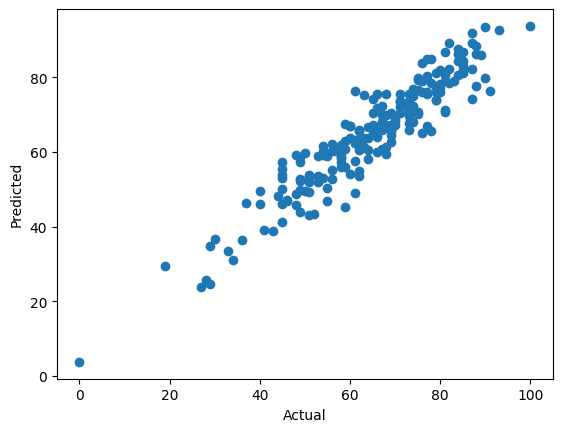

In [51]:
plt.scatter(test_y, y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

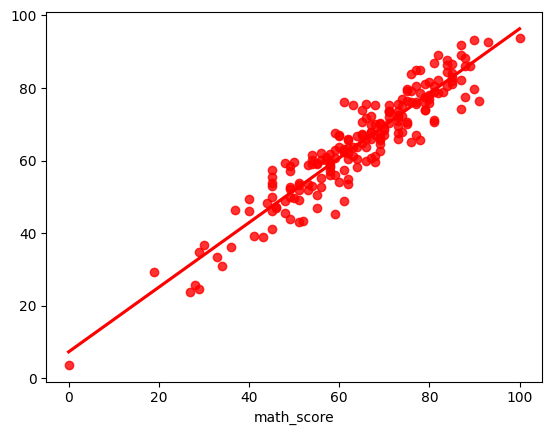

In [52]:
sns.regplot(x=test_y,y=y_pred,ci=None,color ='red');


In [53]:
pred_df=pd.DataFrame({'Actual Value':test_y,'Predicted Value':y_pred,'Difference':test_y-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
